In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import copy
import os
import time

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (
    accuracy_score, 
    f1_score, 
    confusion_matrix, 
    matthews_corrcoef, 
    classification_report
)
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance

%matplotlib inline

print("Всі бібліотеки імпортовано.")

Всі бібліотеки імпортовано.


In [2]:
data_path = 'synthetic_coffee_health_10000.csv'

if os.path.exists(data_path):
    df = pd.read_csv(data_path)
    print("Датасет завантажено з файлу:", data_path, "форма:", df.shape)
else:
    print(f"Файл '{data_path}' не знайдено. Генерую новий синтетичний датасет (10,000 зразків)...")
    np.random.seed(123)
    N = 10000
    
    ids = np.arange(1, N+1)
    age = np.random.randint(20, 75, size=N)
    gender = np.random.choice(['Male','Female','Other'], size=N, p=[0.48,0.49,0.03])
    countries = np.random.choice(['USA','UK','France','Germany','India','Brazil','Kenya','Canada'], size=N)
    occupation = np.random.choice(['Office','Service','Healthcare','Student','Retired','Other'], size=N)
    
    coffee_intake = np.clip(np.round(np.random.gamma(2.2, 1.5, size=N), 1), 0, 15)
    caffeine_mg = coffee_intake * np.random.normal(95, 12, size=N)
    sleep_hours = np.clip(np.round(np.random.normal(7, 1.3, size=N), 1), 3, 10)
    sleep_quality = np.random.choice(['Poor','Fair','Good','Excellent'], size=N, p=[0.15,0.30,0.45,0.10])
    stress_level = np.random.choice(['Low','Medium','High'], size=N, p=[0.40,0.40,0.20])
    smoking = np.random.randint(0, 2, size=N)
    alcohol = np.random.randint(0, 2, size=N)
    
    bmi = np.clip(np.round(np.random.normal(25, 4.5, size=N), 1), 15, 40)
    heart_rate = np.round(np.random.normal(72, 11, size=N)).astype(int)
    physical_activity = np.clip(np.round(np.random.exponential(2.0, size=N), 1), 0, 20)
    
    # Формула для health score
    score = (coffee_intake/5.0) - (sleep_hours/7.5) + \
            (np.isin(stress_level, ['High']).astype(int) * 1.0) + \
            (smoking * 0.8) + (alcohol * 0.6) + \
            ((bmi-24)/12.0) - (physical_activity/8.0) + \
            np.random.normal(0, 0.6, size=N)
    
    # Квантилі для класів
    q = np.quantile(score, [0.28, 0.52, 0.78])
    health_issues = np.where(score <= q[0], 'None', 
                             np.where(score <= q[1], 'Mild', 
                                     np.where(score <= q[2], 'Moderate', 'Severe')))
    
    df = pd.DataFrame({
        'ID': ids,
        'Age': age,
        'Gender': gender,
        'Country': countries,
        'Coffee_Intake': coffee_intake,
        'Caffeine_mg': np.round(caffeine_mg, 1),
        'Sleep_Hours': sleep_hours,
        'Sleep_Quality': sleep_quality,
        'BMI': bmi,
        'Heart_Rate': heart_rate,
        'Stress_Level': stress_level,
        'Physical_Activity_Hours': physical_activity,
        'Health_Issues': health_issues,
        'Occupation': occupation,
        'Smoking': smoking,
        'Alcohol_Consumption': alcohol
    })
    
    df.to_csv(data_path, index=False)
    print("Синтетичний датасет згенеровано та збережено.")

print("Датасет готовий — форма:", df.shape)
display(df.head())


Датасет завантажено з файлу: synthetic_coffee_health_10000.csv форма: (10000, 16)
Датасет готовий — форма: (10000, 16)


,ID,Age,Gender,Country,Coffee_Intake,Caffeine_mg,Sleep_Hours,Sleep_Quality,BMI,Heart_Rate,Stress_Level,Physical_Activity_Hours,Health_Issues,Occupation,Smoking,Alcohol_Consumption
0,1,65,Female,Kenya,2.5,179.9,5.5,Poor,24.3,75,Low,1.1,Moderate,Office,1,1
1,2,22,Female,France,3.7,370.3,7.7,Fair,25.3,72,Medium,0.4,Mild,Healthcare,1,0
2,3,48,Female,Brazil,1.5,147.0,9.5,Good,34.3,55,High,0.8,Severe,Other,1,1
3,4,54,Female,Germany,0.4,43.1,5.9,Fair,25.1,71,High,5.7,Mild,Other,0,1
4,5,58,Female,France,3.7,456.4,6.4,Fair,23.0,60,Medium,0.0,Mild,Retired,1,0


In [3]:
print("\nПочатковий розмір:", df.shape)

nan_y_count = df['Health_Issues'].isnull().sum()
if nan_y_count > 0:
    print(f"Знайдено {nan_y_count} рядків з відсутньою цільовою змінною. Видаляю їх...")
    df = df.dropna(subset=['Health_Issues'])

feature_cols = df.columns.drop(['ID', 'Health_Issues'])
nan_x_count = df[feature_cols].isnull().any(axis=1).sum()

if nan_x_count > 0:
    print(f"Знайдено {nan_x_count} рядків з відсутніми ознаками. Видаляю їх...")
    df = df.dropna(subset=feature_cols)

print(f"Розмір після очистки: {df.shape}. Дані готові до обробки.")


Початковий розмір: (10000, 16)
Знайдено 2800 рядків з відсутньою цільовою змінною. Видаляю їх...
Розмір після очистки: (7200, 16). Дані готові до обробки.


In [4]:
X = df.drop(['ID','Health_Issues'], axis=1)
y = df['Health_Issues']

# Нові інтеракції
X['Coffee_Sleep_Interaction'] = X['Coffee_Intake'] * X['Sleep_Hours']
X['Caffeine_BMI_Ratio'] = X['Caffeine_mg'] / (X['BMI'] + 1)
X['Activity_Sleep_Balance'] = X['Physical_Activity_Hours'] / (X['Sleep_Hours'] + 0.1)
X['Age_Binned'] = pd.cut(X['Age'], bins=[19, 35, 50, 75], labels=['Young', 'Middle', 'Senior'])

print("Інженерію ознак завершено.")
display(X[['Age', 'Age_Binned', 'Coffee_Intake', 'Sleep_Hours', 'Coffee_Sleep_Interaction']].head())

Інженерію ознак завершено.


,Age,Age_Binned,Coffee_Intake,Sleep_Hours,Coffee_Sleep_Interaction
0,65,Senior,2.5,5.5,13.75
1,22,Young,3.7,7.7,28.49
2,48,Middle,1.5,9.5,14.25
3,54,Senior,0.4,5.9,2.36
4,58,Senior,3.7,6.4,23.68


In [5]:
cat_cols = ['Gender', 'Country', 'Occupation', 'Sleep_Quality', 'Stress_Level', 'Age_Binned']

X_encoded = pd.get_dummies(X, columns=cat_cols, drop_first=True)

print(f"\nКількість ознак до кодування: {X.shape[1]}")
print(f"Кількість ознак після кодування: {X_encoded.shape[1]}")


Кількість ознак до кодування: 18
Кількість ознак після кодування: 33


In [6]:
num_cols = ['Age', 'Coffee_Intake', 'Caffeine_mg', 'Sleep_Hours', 'BMI',
            'Heart_Rate', 'Physical_Activity_Hours', 'Smoking', 'Alcohol_Consumption',
            'Coffee_Sleep_Interaction', 'Caffeine_BMI_Ratio', 'Activity_Sleep_Balance']

scaler = StandardScaler()
X_encoded[num_cols] = scaler.fit_transform(X_encoded[num_cols])

print("Масштабування числових ознак завершено.")

feature_names = X_encoded.columns.tolist()
display(X_encoded.head())


Масштабування числових ознак завершено.


,Age,Coffee_Intake,Caffeine_mg,Sleep_Hours,BMI,Heart_Rate,Physical_Activity_Hours,Smoking,Alcohol_Consumption,Coffee_Sleep_Interaction,...,Occupation_Retired,Occupation_Service,Occupation_Student,Sleep_Quality_Fair,Sleep_Quality_Good,Sleep_Quality_Poor,Stress_Level_Low,Stress_Level_Medium,Age_Binned_Middle,Age_Binned_Senior
0,1.138080,-0.484973,-0.723427,-1.086388,-0.308184,0.278968,-0.386071,0.827170,0.878190,-0.660088,...,False,False,False,False,False,True,True,False,False,True
1,-1.571781,0.026834,0.108616,0.615896,-0.080443,0.003103,-0.794320,0.827170,-1.138706,0.185523,...,False,False,False,True,False,False,False,True,False,False
2,0.066740,-0.911479,-0.867199,2.008673,1.969225,-1.560127,-0.561035,0.827170,0.878190,-0.631404,...,False,False,False,False,True,False,False,False,True,False
3,0.444860,-1.380636,-1.321239,-0.776882,-0.125991,-0.088851,2.296709,-1.208941,0.878190,-1.313514,...,False,False,False,True,False,False,False,False,False,True
4,0.696940,0.026834,0.484871,-0.389999,-0.604247,-1.100354,-1.027605,0.827170,-1.138706,-0.090419,...,True,False,False,True,False,False,False,True,False,True


In [ ]:
X_temp, X_test, y_temp, y_test = train_test_split(
    X_encoded, 
    y, 
    test_size=0.20,
    stratify=y, 
    random_state=99
)

X_train, X_val, y_train, y_val = train_test_split(
    X_temp, 
    y_temp, 
    test_size=0.25,  
    stratify=y_temp, 
    random_state=99
)

print("Розбиття даних завершено:")
print("Train:", X_train.shape, y_train.shape)
print("Val:", X_val.shape, y_val.shape)
print("Test:", X_test.shape, y_test.shape)

Розбиття даних завершено:
Train: (4320, 33) (4320,)
Val: (1440, 33) (1440,)
Test: (1440, 33) (1440,)


In [8]:
le = LabelEncoder()

y_train_enc = le.fit_transform(y_train)
y_val_enc = le.transform(y_val)
y_test_enc = le.transform(y_test)

class_names = le.classes_
print("\nКласи (Health_Issues):", list(class_names))
print("Приклад перетворення y_train:", y_train.values[:5])
print("Приклад закодованого y_train_enc:", y_train_enc[:5])


Класи (Health_Issues): ['Mild', 'Moderate', 'Severe']
Приклад перетворення y_train: ['Mild' 'Severe' 'Mild' 'Severe' 'Moderate']
Приклад закодованого y_train_enc: [0 2 0 2 1]


In [9]:
class MyDecisionTree:
    def __init__(self, max_depth=6, min_samples=5):
        self.max_depth = max_depth
        self.min_samples = min_samples
        self.feature_importance = None
        self.tree = None
        self.n_total = None

    def gini(self, y):
        if len(y) == 0: 
            return 0.0
        _, counts = np.unique(y, return_counts=True)
        p = counts / counts.sum()
        return 1.0 - np.sum(p**2)

    def best_split(self, X, y):
        best_gini = float('inf')
        best_feat = None
        best_thr = None
        n, m = X.shape
        
        if n <= 1: 
            return None, None, None, None
            
        parent_gini = self.gini(y)
        
        for feature in range(m):
            vals = np.unique(X[:, feature])
            if len(vals) == 1: 
                continue
                
            sorted_vals = np.sort(vals)
            thresholds = (sorted_vals[:-1] + sorted_vals[1:]) / 2.0
            
            for thr in thresholds:
                left_idx = X[:, feature] <= thr
                right_idx = ~left_idx
                
                if left_idx.sum() < self.min_samples or right_idx.sum() < self.min_samples:
                    continue
                    
                g_left = self.gini(y[left_idx])
                g_right = self.gini(y[right_idx])
                
                g_weighted = (left_idx.sum() / n) * g_left + (right_idx.sum() / n) * g_right
                
                if g_weighted < best_gini:
                    best_gini = g_weighted
                    best_feat = feature
                    best_thr = thr
                    
        return best_feat, best_thr, best_gini, parent_gini

    def build_tree(self, X, y, depth=0):
        node = {}
        num_samples = len(y)
        
        values, counts = np.unique(y, return_counts=True)
        majority_class = int(values[np.argmax(counts)])
        
        node['n_samples'] = int(num_samples)
        node['class'] = majority_class
        node['gini'] = float(self.gini(y))

        if depth >= self.max_depth or num_samples < self.min_samples or node['gini'] == 0.0:
            node['leaf'] = True
            return node

        feat, thr, best_gini, parent_gini = self.best_split(X, y)
        
        if feat is None:
            node['leaf'] = True
            return node
            
        node['leaf'] = False
        node['feature'] = int(feat)
        node['threshold'] = float(thr)
        
        n = num_samples
        left_mask = X[:, feat] <= thr
        right_mask = ~left_mask

        n_left = int(left_mask.sum())
        n_right = int(right_mask.sum())
        
        if n_left > 0 and n_right > 0:
            g_left = self.gini(y[left_mask])
            g_right = self.gini(y[right_mask])
            g_weighted = (n_left / n) * g_left + (n_right / n) * g_right
            
            importance_contrib = (n / self.n_total) * (parent_gini - g_weighted)
            self.feature_importance[feat] += importance_contrib
        
        node['left'] = self.build_tree(X[left_mask], y[left_mask], depth + 1)
        node['right'] = self.build_tree(X[right_mask], y[right_mask], depth + 1)
        return node

    def fit(self, X, y):
        X = np.array(X, dtype=float)
        y = np.array(y, dtype=int)
        self.n_total = len(y)
        
        self.feature_importance = np.zeros(X.shape[1], dtype=float)
        self.tree = self.build_tree(X, y, depth=0)
        
        s = np.sum(self.feature_importance)
        if s > 0:
            self.feature_importance = self.feature_importance / s
        return self

    def predict_one(self, x, node):
        if node.get('leaf', False):
            return int(node['class'])
        if x[node['feature']] <= node['threshold']:
            return self.predict_one(x, node['left'])
        else:
            return self.predict_one(x, node['right'])

    def predict(self, X):
        X = np.array(X, dtype=float)
        return np.array([self.predict_one(x, self.tree) for x in X], dtype=int)
    
    def count_leaves(self, node):
        if node.get('leaf', False):
            return 1
        if 'left' not in node or 'right' not in node:
            return 1 
        return self.count_leaves(node['left']) + self.count_leaves(node['right'])

    def calculate_error(self, X_val, y_val, node):
        if len(y_val) == 0: 
            return 0.0
        preds = np.full(len(y_val), node['class'], dtype=int)
        return np.sum(preds != y_val) / len(y_val)

    def prune_tree(self, node, alpha, X_val, y_val):
        if node.get('leaf', False):
            return self.calculate_error(X_val, y_val, node)
            
        feat = node['feature']
        thr = node['threshold']
        
        left_mask = X_val[:, feat] <= thr
        right_mask = ~left_mask
        
        X_val_left, y_val_left = X_val[left_mask], y_val[left_mask]
        X_val_right, y_val_right = X_val[right_mask], y_val[right_mask]

        left_error = self.prune_tree(node['left'], alpha, X_val_left, y_val_left)
        right_error = self.prune_tree(node['right'], alpha, X_val_right, y_val_right)
        
        total_val = len(y_val)
        
        if total_val > 0:
            def predict_subtree(x_row, node_local):
                if node_local.get('leaf', False): return node_local['class']
                if x_row[node_local['feature']] <= node_local['threshold']:
                    return predict_subtree(x_row, node_local['left'])
                else:
                    return predict_subtree(x_row, node_local['right'])
            
            preds = np.array([predict_subtree(x, node) for x in X_val])
            subtree_mis = np.sum(preds != y_val) / total_val
        else:
            subtree_mis = 0.0
            
        leaf_error = self.calculate_error(X_val, y_val, {'leaf': True, 'class': node['class']})
        leaves = self.count_leaves(node)
        
        if (leaf_error + alpha) <= (subtree_mis + alpha * (leaves - 1)):
            node['leaf'] = True
            node.pop('left', None)
            node.pop('right', None)
            node.pop('feature', None)
            node.pop('threshold', None)
            return leaf_error
        else:
            return subtree_mis

print("Клас MyDecisionTree реалізовано.")

Клас MyDecisionTree реалізовано.


In [10]:
tree = MyDecisionTree(max_depth=9, min_samples=12)

print("Починаю навчання MyDecisionTree...")
start_time = time.time()

tree.fit(X_train.values, y_train_enc)

print(f"Навчання завершено за {time.time() - start_time:.2f} сек.")

# Отримуємо прогнози
pred_train = tree.predict(X_train.values)
pred_val = tree.predict(X_val.values)
pred_test = tree.predict(X_test.values)

# Розраховуємо метрики
acc_train = accuracy_score(y_train_enc, pred_train)
acc_val = accuracy_score(y_val_enc, pred_val)
acc_test = accuracy_score(y_test_enc, pred_test)

f1_test = f1_score(y_test_enc, pred_test, average='macro')
mcc_test = matthews_corrcoef(y_test_enc, pred_test)
cm_test = confusion_matrix(y_test_enc, pred_test)

print("\n--- MyDecisionTree (До Прунінгу) ---")
print("MyDecisionTree — before pruning: Train acc {:.3f}, Val acc {:.3f}, Test acc {:.3f}, Test F1 {:.3f}, MCC {:.3f}".format(
    acc_train, acc_val, acc_test, f1_test, mcc_test
))
print("Confusion matrix (test):\n", cm_test)

Починаю навчання MyDecisionTree...
Навчання завершено за 11.06 сек.

--- MyDecisionTree (До Прунінгу) ---
MyDecisionTree — before pruning: Train acc 0.688, Val acc 0.518, Test acc 0.526, Test F1 0.530, MCC 0.286
Confusion matrix (test):
 [[279 155  46]
 [173 228 119]
 [ 45 145 250]]


In [11]:
def prune_via_validation(tree_obj, X_val, y_val, alphas=[0.0, 0.0005, 0.001, 0.002, 0.005, 0.01, 0.02]):
    """
    Допоміжна функція для пошуку найкращого alpha
    """
    best_alpha = None
    best_err = 1.0
    best_tree = None
    
    # Конвертуємо у numpy один раз
    X_val_np = np.array(X_val, dtype=float)
    y_val_np = np.array(y_val, dtype=int)
    
    print("\n--- Пошук найкращого Alpha (Прунінг) ---")
    
    for a in alphas:
        # Копіюємо оригінальне дерево
        tree_copy = copy.deepcopy(tree_obj.tree)
        # Зберігаємо посилання на старе дерево
        old_tree = tree_obj.tree
        tree_obj.tree = tree_copy  # Тимчасово встановлюємо копію
        
        # Запускаємо рекурсивний прунінг (який змінює tree_copy)
        tree_obj.prune_tree(tree_obj.tree, a, X_val_np, y_val_np)
        
        # Оцінюємо обрізане дерево
        preds_val = tree_obj.predict(X_val_np) 
        
        val_err = np.sum(preds_val != y_val_np) / len(y_val_np) if len(y_val_np) > 0 else 0.0
        
        print(f"Alpha={a:.4f}, Val Error={val_err:.4f}, Листів={tree_obj.count_leaves(tree_obj.tree)}")
        
        # Шукаємо найменшу помилку
        if val_err < best_err:
            best_err = val_err
            best_alpha = a
            best_tree = copy.deepcopy(tree_obj.tree)  # Зберігаємо найкраще дерево
            
        # Відновлюємо оригінальне дерево в об'єкті
        tree_obj.tree = old_tree
        
    return best_alpha, best_err, best_tree

# Запускаємо пошук
best_alpha, best_err, best_tree = prune_via_validation(tree, X_val.values, y_val_enc)

print(f"\nНайкращий Alpha: {best_alpha} (Validation error: {best_err:.4f})")

# Застосовуємо найкраще обрізане дерево
if best_tree is not None:
    tree.tree = best_tree  # Замінюємо дерево в нашому об'єкті на обрізане
    
    # Оцінюємо обрізане дерево на тестових даних
    pred_test_pruned = tree.predict(X_test.values)
    acc_test_pruned = accuracy_score(y_test_enc, pred_test_pruned)
    f1_test_pruned = f1_score(y_test_enc, pred_test_pruned, average='macro')
    mcc_test_pruned = matthews_corrcoef(y_test_enc, pred_test_pruned)
    cm_test_pruned = confusion_matrix(y_test_enc, pred_test_pruned)
    
    print("--- MyDecisionTree (Після Прунінгу) ---")
    print("After pruning: Test acc {:.3f}, F1 {:.3f}, MCC {:.3f}".format(
        acc_test_pruned, f1_test_pruned, mcc_test_pruned
    ))
else:
    # Зберігаємо старі результати, якщо прунінг не дав покращення
    pred_test_pruned = pred_test
    cm_test_pruned = cm_test
    acc_test_pruned = acc_test
    f1_test_pruned = f1_test
    mcc_test_pruned = mcc_test
    print("Покращення від прунінгу не знайдено.")


--- Пошук найкращого Alpha (Прунінг) ---
Alpha=0.0000, Val Error=0.4354, Листів=74
Alpha=0.0005, Val Error=0.4354, Листів=74
Alpha=0.0010, Val Error=0.4354, Листів=74
Alpha=0.0020, Val Error=0.4361, Листів=68
Alpha=0.0050, Val Error=0.5764, Листів=9
Alpha=0.0100, Val Error=0.5563, Листів=3
Alpha=0.0200, Val Error=0.5563, Листів=3

Найкращий Alpha: 0.0 (Validation error: 0.4354)
--- MyDecisionTree (Після Прунінгу) ---
After pruning: Test acc 0.551, F1 0.557, MCC 0.323


In [12]:
print("\nНавчаю моделі sklearn для порівняння...")

# 1. sklearn DecisionTree
dt_sk = DecisionTreeClassifier(
    criterion='gini', 
    max_depth=9,      
    min_samples_leaf=12, 
    random_state=99
)
dt_sk.fit(X_train, y_train_enc)  # sklearn приймає Pandas
pred_dt_sk = dt_sk.predict(X_test)

# 2. sklearn RandomForest
rf = RandomForestClassifier(
    n_estimators=120,
    max_depth=11,
    random_state=99
)
rf.fit(X_train, y_train_enc)
pred_rf = rf.predict(X_test)

print("Моделі sklearn навчено.")

# 3. Функція для збору метрик
def compute_metrics(y_true, y_pred, name):
    return {
        'model': name,
        'accuracy': accuracy_score(y_true, y_pred),
        'f1_macro': f1_score(y_true, y_pred, average='macro'),
        'mcc': matthews_corrcoef(y_true, y_pred)
    }

metrics = [
    compute_metrics(y_test_enc, pred_test, 'MyDecisionTree (unpruned)'),
    compute_metrics(y_test_enc, pred_test_pruned, 'MyDecisionTree (pruned)'),
    compute_metrics(y_test_enc, pred_dt_sk, 'sklearn DecisionTree'),
    compute_metrics(y_test_enc, pred_rf, 'RandomForest')
]

metrics_df = pd.DataFrame(metrics)

print("\n--- Фінальна Таблиця Метрик (Порівняння) ---")
# Використовуємо .to_string() для гарного виводу
print(metrics_df.to_string(index=False))



Навчаю моделі sklearn для порівняння...
Моделі sklearn навчено.

--- Фінальна Таблиця Метрик (Порівняння) ---
                    model  accuracy  f1_macro      mcc
MyDecisionTree (unpruned)  0.525694  0.530349 0.286310
  MyDecisionTree (pruned)  0.550694  0.556531 0.323394
     sklearn DecisionTree  0.523611  0.528195 0.283139
             RandomForest  0.543750  0.549287 0.313127



--- Візуалізація: Матриці помилок (Test) ---


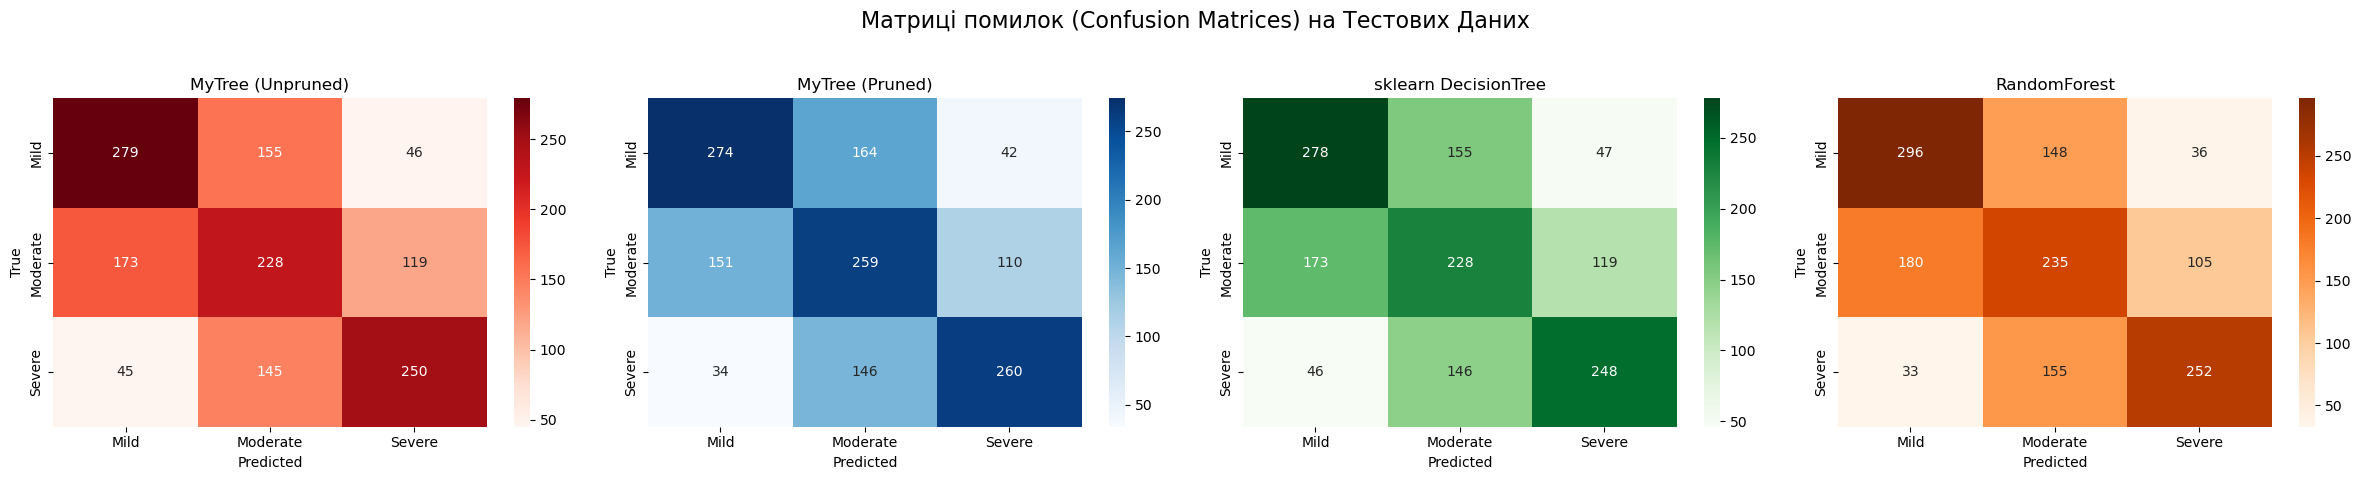

In [13]:
print("\n--- Візуалізація: Матриці помилок (Test) ---")
plt.rcParams.update({'figure.max_open_warning': 0}) 

fig, axs = plt.subplots(1, 4, figsize=(24, 5))
fig.suptitle("Матриці помилок (Confusion Matrices) на Тестових Даних", fontsize=16)

# Графік 0: MyTree (Unpruned)
cm_unpruned = confusion_matrix(y_test_enc, pred_test)
sns.heatmap(cm_unpruned, annot=True, fmt='d', cmap='Reds', ax=axs[0],
            xticklabels=class_names, yticklabels=class_names)
axs[0].set_title('MyTree (Unpruned)')
axs[0].set_xlabel('Predicted')
axs[0].set_ylabel('True')

# Графік 1: MyTree (Pruned)
cm_pruned = confusion_matrix(y_test_enc, pred_test_pruned)
sns.heatmap(cm_pruned, annot=True, fmt='d', cmap='Blues', ax=axs[1],
            xticklabels=class_names, yticklabels=class_names)
axs[1].set_title('MyTree (Pruned)')
axs[1].set_xlabel('Predicted')
axs[1].set_ylabel('True')

# Графік 2: sklearn DT
cm_sk = confusion_matrix(y_test_enc, pred_dt_sk)
sns.heatmap(cm_sk, annot=True, fmt='d', cmap='Greens', ax=axs[2],
            xticklabels=class_names, yticklabels=class_names)
axs[2].set_title('sklearn DecisionTree')
axs[2].set_xlabel('Predicted')
axs[2].set_ylabel('True')

# Графік 3: RandomForest
cm_rf = confusion_matrix(y_test_enc, pred_rf)
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Oranges', ax=axs[3],
            xticklabels=class_names, yticklabels=class_names)
axs[3].set_title('RandomForest')
axs[3].set_xlabel('Predicted')
axs[3].set_ylabel('True')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()




--- Візуалізація: Важливість Ознак (Top 15) ---


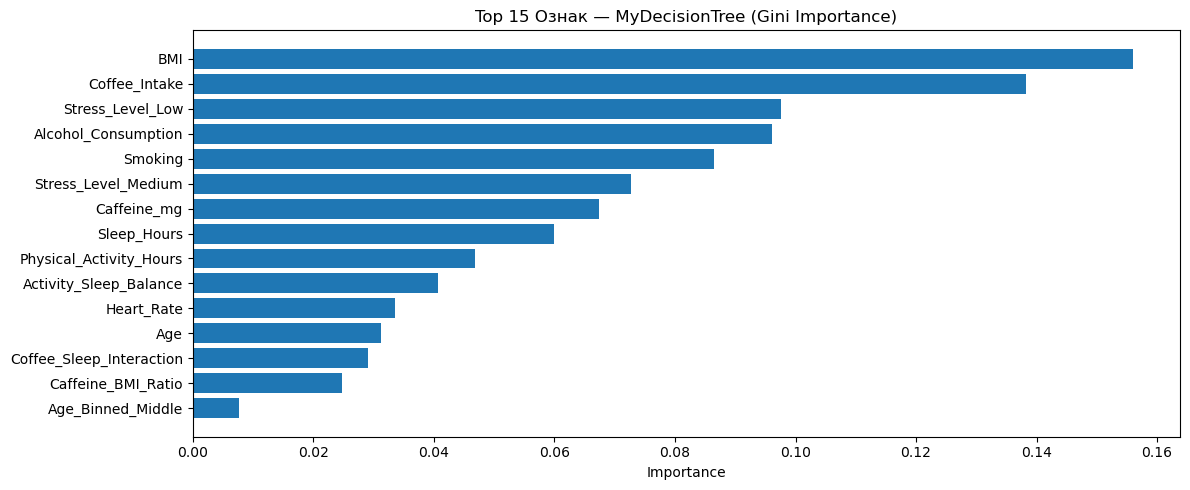

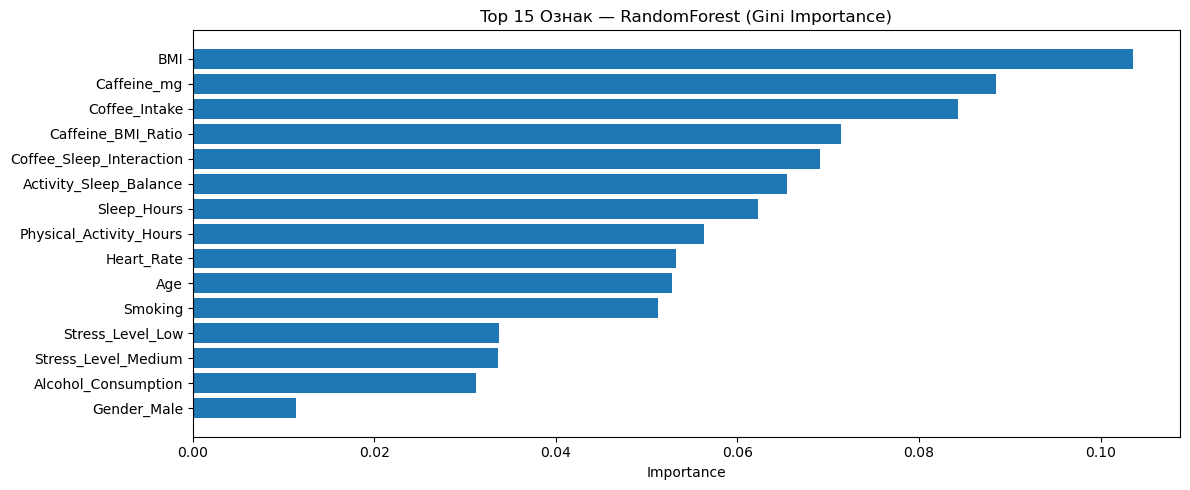

In [14]:
print("\n--- Візуалізація: Важливість Ознак (Top 15) ---")

my_imp = tree.feature_importance
rf_imp = rf.feature_importances_

# Top 15 для MyTree
top_idx_my = np.argsort(my_imp)[-15:][::-1]
plt.figure(figsize=(12, 5))
plt.barh([feature_names[i] for i in top_idx_my[::-1]], my_imp[top_idx_my[::-1]])
plt.title('Top 15 Ознак — MyDecisionTree (Gini Importance)')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

# Top 15 для RandomForest
top_idx_rf = np.argsort(rf_imp)[-15:][::-1]
plt.figure(figsize=(12, 5))
plt.barh([feature_names[i] for i in top_idx_rf[::-1]], rf_imp[top_idx_rf[::-1]])
plt.title('Top 15 Ознак — RandomForest (Gini Importance)')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()


Розрахунок Permutation Importance для RandomForest...


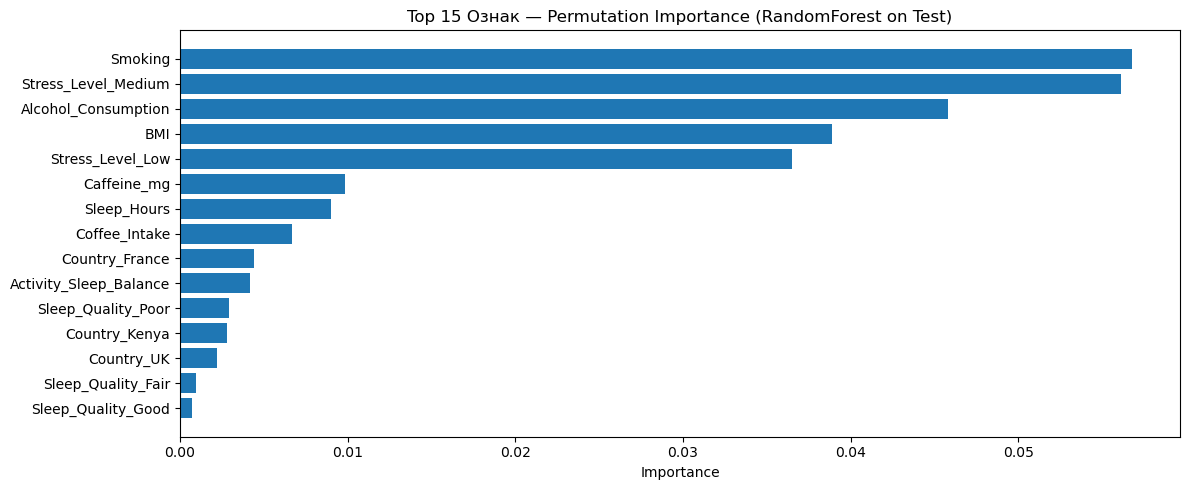

In [15]:
print("\nРозрахунок Permutation Importance для RandomForest...")
perm = permutation_importance(rf, X_test, y_test_enc, n_repeats=5, random_state=99)
perm_imp = perm.importances_mean
top_perm_idx = np.argsort(perm_imp)[-15:][::-1]

plt.figure(figsize=(12, 5))
plt.barh([feature_names[i] for i in top_perm_idx[::-1]], perm_imp[top_perm_idx[::-1]])
plt.title('Top 15 Ознак — Permutation Importance (RandomForest on Test)')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()


In [16]:
# 1. Відбір Топ-10 ознак за важливістю від MyDecisionTree
top10_indices = np.argsort(my_imp)[-10:]
top10_features = [feature_names[i] for i in top10_indices]
print(f"\nTop-10 Ознак (за MyDecisionTree): {top10_features}")

# 2. Створюємо нові набори даних
X_train_sel = X_train[top10_features]
X_test_sel = X_test[top10_features]

# 3. Повторне навчання на обраних ознаках
dt_sk2 = DecisionTreeClassifier(
    criterion='gini', 
    max_depth=9, 
    min_samples_leaf=12, 
    random_state=99
)
dt_sk2.fit(X_train_sel, y_train_enc)
pred_dt2 = dt_sk2.predict(X_test_sel)

rf2 = RandomForestClassifier(
    n_estimators=120, 
    max_depth=11,
    random_state=99
)
rf2.fit(X_train_sel, y_train_enc)
pred_rf2 = rf2.predict(X_test_sel)

# 4. Оцінка моделей після Feature Selection
metrics2 = [
    compute_metrics(y_test_enc, pred_dt2, 'sklearn DecisionTree (top10)'),
    compute_metrics(y_test_enc, pred_rf2, 'RandomForest (top10)')
]
metrics2_df = pd.DataFrame(metrics2)

print("\n--- Метрики (Після Feature Selection, Top-10) ---")
print(metrics2_df.to_string(index=False))

print("\n--- (Для порівняння) Метрики на Повних даних ---")
print(metrics_df[metrics_df['model'].str.contains('sklearn')].to_string(index=False))



Top-10 Ознак (за MyDecisionTree): ['Activity_Sleep_Balance', 'Physical_Activity_Hours', 'Sleep_Hours', 'Caffeine_mg', 'Stress_Level_Medium', 'Smoking', 'Alcohol_Consumption', 'Stress_Level_Low', 'Coffee_Intake', 'BMI']

--- Метрики (Після Feature Selection, Top-10) ---
                       model  accuracy  f1_macro      mcc
sklearn DecisionTree (top10)  0.523611  0.530665 0.282590
        RandomForest (top10)  0.554167  0.560865 0.328728

--- (Для порівняння) Метрики на Повних даних ---
               model  accuracy  f1_macro      mcc
sklearn DecisionTree  0.523611  0.528195 0.283139
